<Axes: xlabel='structural_heterogeneity', ylabel='Density'>

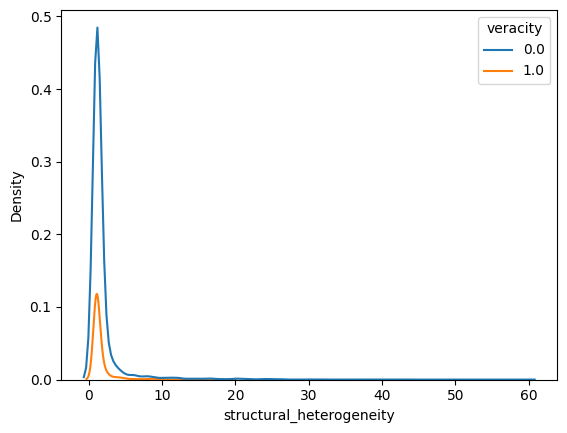

In [21]:
import seaborn as sns

sns.kdeplot(data=X_test, x="structural_heterogeneity", hue=y_test)

<Axes: xlabel='structural_heterogeneity', ylabel='Density'>

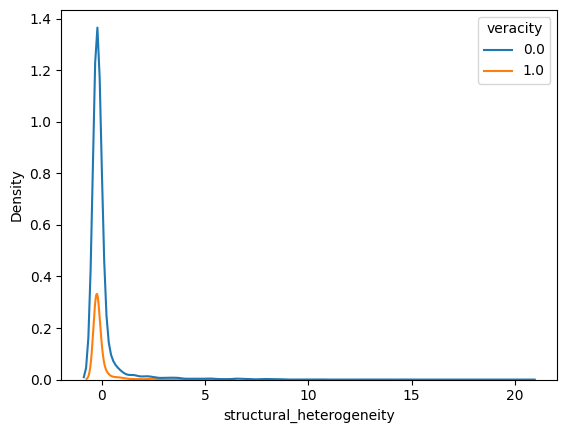

In [23]:
import seaborn as sns

sns.kdeplot(data=scaled_X_test, x="structural_heterogeneity", hue=y_test)

In [1]:
# # this piece of code will download the models from wandb 
# # for a particular project and then renames the folder accordingly
# # please avoid running this code all the time to avoid confusion

# import os
# import wandb

# os.environ["WANDB_API_KEY"] = "b21f4406f3966154b12e98de3bef934216952a54"
# os.environ["WANDB_ENTITY"] = "istiyaksiddiquee"

# wandb_project = "Appendix1"

# run = wandb.init(project=wandb_project)

# artifact = run.use_artifact(wandb_project + "/Logistic-Model:latest")
# model_dir = artifact.download()

# artifact = run.use_artifact(wandb_project + "/DT-Model:latest")
# model_dir = artifact.download()

# artifact = run.use_artifact(wandb_project + "/RF-Model:latest")
# model_dir = artifact.download()

# artifact = run.use_artifact(wandb_project + "/XGB-Model:latest")
# model_dir = artifact.download()

# artifact = run.use_artifact(wandb_project + "/LGB-Model:latest")
# model_dir = artifact.download()

# artifact = run.use_artifact(wandb_project + "/Default-RF-Cls:latest")
# model_dir = artifact.download()

# artifact = run.use_artifact(wandb_project + "/Stratified-Dummy-Cls:latest")
# model_dir = artifact.download()

# artifact = run.use_artifact(wandb_project + "/Most-Freq-Dummy-Cls:latest")
# model_dir = artifact.download()

# run.finish()

# os.rename('artifacts', wandb_project)

wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: istiyaksiddiquee. Use `wandb login --relogin` to force relogin


wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


In [14]:
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    average_precision_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)
from copy import copy


def get_all_scores(y_real, y_pred, y_scores):
    accuracy = accuracy_score(y_real, y_pred)
    precision = precision_score(y_real, y_pred, average=None)
    recall = recall_score(y_real, y_pred, average=None)
    balanced_accuracy = balanced_accuracy_score(y_real, y_pred)
    fbeta = fbeta_score(y_real, y_pred, beta=0.5)
    avg_precision = average_precision_score(y_real, y_scores)
    roc_auc = roc_auc_score(y_real, y_scores)

    return {
        "average_precision": round(avg_precision, 2), 
        "precision_0": round(precision[0], 2), 
        "precision_1": round(precision[1], 2), 
        "recall_0": round(recall[0], 2), 
        "recall_1": round(recall[1], 2), 
        "roc_auc": round(roc_auc, 2),
        "balanced_accuracy": round(balanced_accuracy, 2),
        "fbeta": round(fbeta, 2), 
        "accuracy": round(accuracy, 2), 
    }

def flip_true_false(y):
    copy_y = copy(y)
    flipped_y = [0 if item == 1 else 1 for item in copy_y]
    return flipped_y

def test_model(model, scaled_X_test_df, y_test):
    y_pred = model.predict(scaled_X_test_df)
    y_pred_proba = model.predict_proba(scaled_X_test_df)
    
    return get_all_scores(y_test, y_pred, y_pred_proba[:, 1])

def get_confusion_matrix(model, scaled_X_test_df, y_test):
    y_pred = model.predict(scaled_X_test_df)
    return confusion_matrix(y_test, y_pred)
    
    # flipped_y = flip_true_false(y_pred)
    # print(get_all_scores(y_test, flipped_y, y_pred_proba[:, 0]))
    

In [2]:
# accuracy, precision, recall, balanced_accuracy, fbeta, avg_precision, roc_auc
import joblib
import pandas as pd

def performance_testing(project, scaled_X_test_df, y_test):

    logit_model = joblib.load(f'./{project}/Logistic-Model-v0/logit.joblib')
    logit_scores = test_model(logit_model, scaled_X_test_df, y_test)

    dt_model = joblib.load(f'./{project}/DT-Model-v0/dt.joblib')
    dt_scores = test_model(dt_model, scaled_X_test_df, y_test)

    rf_model = joblib.load(f'./{project}/RF-Model-v0/rf.joblib')
    rf_scores = test_model(rf_model, scaled_X_test_df, y_test)

    xgb_model = joblib.load(f'./{project}/XGB-Model-v0/xgb.joblib')
    xgb_scores = test_model(xgb_model, scaled_X_test_df, y_test)

    lgb_model = joblib.load(f'./{project}/LGB-Model-v0/lgb.joblib')
    lgb_scores = test_model(lgb_model, scaled_X_test_df, y_test)
    
    default_rf_model = joblib.load(f'./{project}/Default-RF-Cls-v0/default_rf.joblib')
    default_rf_scores = test_model(default_rf_model, scaled_X_test_df, y_test)

    freq_dummy_model = joblib.load(f'./{project}/Most-Freq-Dummy-Cls-v0/most_freq_dummy_cls.joblib')
    freq_dummy_scores = test_model(freq_dummy_model, scaled_X_test_df, y_test)

    stratified_dummy_model = joblib.load(f'./{project}/Stratified-Dummy-Cls-v0/stratified_dummy_cls.joblib')
    stratified_dummy_scores = test_model(stratified_dummy_model, scaled_X_test_df, y_test)

    # result_df = pd.DataFrame(
    #     [
    #     logit_scores, dt_scores, rf_scores, xgb_scores, lgb_scores, default_rf_scores, stratified_dummy_scores, freq_dummy_scores
    #     ],
    #     index=['logit_scores', 'dt_scores', 'rf_scores', 'xgb_scores', 'lgb_scores', 'default_rf_scores', 'stratified_dummy_scores', 'freq_dummy_scores']
    # )
    
    result_df = pd.DataFrame(
        [
        logit_scores, dt_scores, rf_scores, xgb_scores, lgb_scores, stratified_dummy_scores, freq_dummy_scores        ],
        index=['logit_scores', 'dt_scores', 'rf_scores', 'xgb_scores', 'lgb_scores', 'stratified_dummy_scores', 'freq_dummy_scores']
    )

    # return result_df.sort_values(by='average_precision', ascending=False)
    return result_df

In [3]:
def best_performing_model(project, result_df):
    model = None
    
    res = result_df.sort_values(by='average_precision', ascending=False)
    names = ['logit_scores', 'dt_scores', 'rf_scores', 'lgb_scores', 'xgb_scores', 'default_rf_scores', 'freq_dummy_scores', 'stratified_dummy_scores']
    if res.iloc[0].name == 'logit_scores':
        model = joblib.load(f'./{project}/Logistic-Model-v0/logit.joblib')
    elif res.iloc[0].name == 'dt_scores':
        model = joblib.load(f'./{project}/DT-Model-v0/dt.joblib')
    elif res.iloc[0].name == 'rf_scores':
        model = joblib.load(f'./{project}/RF-Model-v0/rf.joblib')
    elif res.iloc[0].name == 'lgb_scores':
        model = joblib.load(f'./{project}/LGB-Model-v0/lgb.joblib')
    elif res.iloc[0].name == 'xgb_scores':
        model = joblib.load(f'./{project}/XGB-Model-v0/xgb.joblib')
    elif res.iloc[0].name == 'default_rf_scores':
        model = joblib.load(f'./{project}/Default-RF-Cls-v0/default_rf.joblib')
    elif res.iloc[0].name == 'freq_dummy_scores':
        model = joblib.load(f'./{project}/Most-Freq-Dummy-Cls-v0/most_freq_dummy_cls.joblib')
    elif res.iloc[0].name == 'stratified_dummy_scores':
        model = joblib.load(f'./{project}/Stratified-Dummy-Cls-v0/stratified_dummy_cls.joblib')
    
    freq_model = joblib.load(f'./{project}/Most-Freq-Dummy-Cls-v0/most_freq_dummy_cls.joblib')
    strat_model = joblib.load(f'./{project}/Stratified-Dummy-Cls-v0/stratified_dummy_cls.joblib')
    return model, freq_model, strat_model

# logit_predict_proba = logit_model.predict_proba(scaled_X_test_df)

In [4]:
from copy import copy
import pickle
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer

def read_pickled_data(dataset, feature_selection, quant, dropped_columns, normalization_columns):

    prefix = f'../../datasets-for-exp/{dataset}/{dataset}_'
    order = ['depth', 'size', 'max_breadth', 'virality', 'density', 'layer_ratio',  'structural_heterogeneity',  'characteristic_distance']

    with open(prefix + 'x_train_val.pickle', "rb") as file:
        X_train_val = pickle.load(file)

    with open(prefix + 'y_train_val.pickle' , "rb") as file:
        y_train_val = pickle.load(file)

    with open(prefix + 'x_test.pickle',  "rb") as file:
        X_test = pickle.load(file)

    with open(prefix + 'y_test.pickle',  "rb") as file:
        y_test = pickle.load(file)

    class CustomFunctionTransformer(FunctionTransformer):
        def get_feature_names_out(self, input_features=None):
            return input_features

    log_norm_custom = CustomFunctionTransformer(func=np.log)
    
    if feature_selection == 1:
        order = [item for item in order if item not in dropped_columns]
        normalization_columns = [item for item in normalization_columns if item not in dropped_columns]
        X_train_val.drop(dropped_columns, axis=1, inplace=True)
        X_test.drop(dropped_columns, axis=1, inplace=True)
    
    normalized_df = copy(X_train_val)
    
    scaler = StandardScaler()

    preprocessor = ColumnTransformer([
        ('log_norm', log_norm_custom, normalization_columns),  # Columns to log-normalize
        ('scale', scaler, list(set(list(X_train_val.columns)) - set(normalization_columns)))  # Columns to scale
    ], verbose_feature_names_out=False)

    if quant == True:
        cd_first_quantile = np.quantile(normalized_df["characteristic_distance"], 0.25)
        cd_third_quantile = np.quantile(normalized_df["characteristic_distance"], 0.75)
        normalized_df["characteristic_distance"] = normalized_df["characteristic_distance"] + cd_first_quantile**2 / cd_third_quantile
        
        test_cd_first_quantile = np.quantile(X_test["characteristic_distance"], 0.25)
        test_cd_third_quantile = np.quantile(X_test["characteristic_distance"], 0.75)
        X_test["characteristic_distance"] = X_test["characteristic_distance"] + test_cd_first_quantile**2 / test_cd_third_quantile
        
    scaled_X_train_val = preprocessor.fit_transform(normalized_df)
    scaled_X_test = preprocessor.transform(X_test)

    transformed_columns = list(preprocessor.get_feature_names_out())
    
    # transformed_columns[transformed_columns.index('scale__characteristic_distance')] = 'log_norm__characteristic_distance'
    # original_column_order[original_column_order.index('scale__characteristic_distance')] = 'log_norm__characteristic_distance'
    
    scaled_X_train_val_df = pd.DataFrame(scaled_X_train_val, columns=transformed_columns)
    scaled_X_test_df = pd.DataFrame(scaled_X_test, columns=transformed_columns)
    
    scaled_X_train_val_df =  scaled_X_train_val_df[order]
    scaled_X_test_df =  scaled_X_test_df[order]

    return scaled_X_train_val_df, y_train_val, scaled_X_test_df, y_test


In [5]:
configuration = {
    'RQ2Final1_drop': ['max_breadth'],
    'RQ2Final2_drop': ['max_breadth', 'virality'],
    'RQ3Final1_drop': ['size', 'max_breadth'],
    'RQ3Final2_drop': ['max_breadth'],
    'RQ3Final3_drop': ['size', 'max_breadth', 'virality'],
    'RQ3Final4_drop': ['max_breadth'],
    'RQ4Final1_drop': ['virality'],
    
    'RQ2Final1_norm': ['size', 'max_breadth', 'characteristic_distance'],
    'RQ2Final2_norm': ['size', 'max_breadth', 'characteristic_distance'],
    'RQ3Final1_norm': ['size', 'max_breadth', 'characteristic_distance'],
    'RQ3Final2_norm': ['size', 'max_breadth'],
    'RQ3Final3_norm': ['size', 'max_breadth', 'characteristic_distance'],
    'RQ3Final4_norm': ['size', 'max_breadth', 'characteristic_distance'],
    'RQ4Final1_norm': ['size', 'max_breadth', 'virality', 'layer_ratio', 'structural_heterogeneity', 'characteristic_distance'],
    
    'RQ2Final1_quant': True,
    'RQ2Final2_quant': True,
    'RQ3Final1_quant': True,
    'RQ3Final2_quant': False,
    'RQ3Final3_quant': False,
    'RQ3Final4_quant': True,
    'RQ4Final1_quant': True,
}

In [12]:
folder="RQ2Final2"
quant = configuration[f'{folder}_quant']
feature_selection = 1
dropped_columns = configuration[f'{folder}_drop']
normalization_columns = configuration[f'{folder}_norm']

scaled_X_train_val, y_train_val, scaled_X_test, y_test = read_pickled_data(folder, feature_selection, quant, dropped_columns, normalization_columns)
print(scaled_X_train_val.shape, y_train_val.shape, scaled_X_test.shape, y_test.shape)
result_df = performance_testing(folder, scaled_X_test, y_test)
best_model, freq_model, strat_model = best_performing_model(folder, result_df)
result_df.sort_values(by='average_precision', ascending=False, inplace=True)
result_df[['average_precision', 'roc_auc', 'balanced_accuracy', 'precision_0', 'precision_1', 'recall_0', 'recall_1']]

(1270, 6) (1270,) (142, 6) (142,)


c:\Program Files\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,average_precision,roc_auc,balanced_accuracy,precision_0,precision_1,recall_0,recall_1
stratified_dummy_scores,0.27,0.60,0.54,0.81,0.25,0.56,0.52
lgb_scores,0.25,0.58,0.48,0.77,0.11,0.93,0.03
dt_scores,0.24,0.55,0.49,0.78,0.00,0.98,0.00
logit_scores,0.22,0.48,0.50,0.78,0.22,0.23,0.77
xgb_scores,0.22,0.48,0.48,0.78,0.00,0.96,0.00
freq_dummy_scores,0.22,0.50,0.50,0.78,0.00,1.00,0.00
rf_scores,0.19,0.39,0.50,0.78,0.20,0.96,0.03


In [ ]:
folder="RQ2Final1"
quant = True
feature_selection = 1
dropped_columns = ['max_breadth']
normalization_columns = ['size', 'max_breadth']
# normalization_columns = ['size', 'max_breadth', 'characteristic_distance']

scaled_X_train_val, y_train_val, scaled_X_test, y_test = read_pickled_data(folder, feature_selection, quant, dropped_columns, normalization_columns)
print(scaled_X_train_val.shape, y_train_val.shape, scaled_X_test.shape, y_test.shape)
result_df = performance_testing("RQ3Final2-old", scaled_X_test, y_test)
best_model = best_performing_model(folder, result_df)
# result_df.sort_values(by='average_precision', ascending=False, inplace=True)
result_df[['average_precision', 'roc_auc', 'balanced_accuracy', 'precision_0', 'precision_1', 'recall_0', 'recall_1']]

# arr = read_pickled_data(folder, feature_selection, quant, dropped_columns, normalization_columns)

In [72]:
import numpy as np

# Your PR-AUC scores
group1 = np.array([0.19, 0.16, 0.17, 0.16, 0.18, 0.16, 0.16])  # PR-AUC scores from Dataset A
group2 = np.array([0.3 , 0.17, 0.38, 0.06, 0.33, 0.06, 0.06])

from mlxtend.evaluate import permutation_test

p_value = permutation_test(group1, group2,
                           method='approximate',
                           num_rounds=10000,
                           seed=0)
print(p_value)

0.6525347465253475


In [71]:
import numpy as np
from scipy.stats import mannwhitneyu

# Perform the Mann-Whitney U Test
statistic, p_value = mannwhitneyu(group1, group2, alternative='two-sided')

print(f"Mann-Whitney U statistic: {statistic}")
print(f"P-value: {p_value}")

Mann-Whitney U statistic: 23.5
P-value: 0.9481998574185876


In [104]:
dict = {}
for i in range(5, 9):
    feature_selection = 1
    if i%2 == 0:
        feature_selection = 0
    project = 'RQ2Comb'+str(i)
    print(f"project = {project}, feature_selection = {feature_selection}")
    scaled_X_train_val, y_train_val, scaled_X_test, y_test = read_pickled_data(dataset = "RQ2Final2", feature_selection = feature_selection)
    print(scaled_X_train_val.shape, y_train_val.shape, scaled_X_test.shape, y_test.shape)
    result_df = performance_testing(project = project, scaled_X_test_df=scaled_X_test, y_test=y_test)
    
    dict[project] = list(result_df['average_precision'].values)

project = RQ2Comb5, feature_selection = 1
(1270, 6) (1270,) (142, 6) (142,)
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_gain_to_split is set=0.1, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.1
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_gain_to_split is set=0.1, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.1
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_gain_to_split is set=0.1, min_split_gain=0.0 will be ignored. Current value: min_

In [102]:
feature_array = [
    'Feature1', 'Feature1', 'Feature1', 'Feature1', 'Feature1', 'Feature1', 'Feature1',
    'Feature0', 'Feature0', 'Feature0', 'Feature0', 'Feature0', 'Feature0', 'Feature0', 
    'Feature1', 'Feature1', 'Feature1', 'Feature1', 'Feature1', 'Feature1', 'Feature1',
    'Feature0', 'Feature0', 'Feature0', 'Feature0', 'Feature0', 'Feature0', 'Feature0',
]
smote_array = [
    'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 
    'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 
    'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 
    'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 
]

import numpy as np
result_array = []
for item in dict.keys():
    for k in dict[item]:
        result_array.append(k)

print(np.array(result_array).std(), np.array(result_array).var())

srh_df = pd.DataFrame({
    'feature_state': feature_array,
    'smote_state': smote_array,
    'result': result_array
})

print(result_array)

0.014603605928757766 0.00021326530612244895
[0.21, 0.24, 0.23, 0.22, 0.25, 0.22, 0.25, 0.22, 0.24, 0.23, 0.22, 0.26, 0.22, 0.22, 0.22, 0.22, 0.23, 0.21, 0.25, 0.22, 0.21, 0.2, 0.22, 0.24, 0.22, 0.25, 0.22, 0.22]


In [97]:
srh_df['rank'] = srh_df.result.sort_values().rank(numeric_only = float)

rows = srh_df.groupby(['feature_state'], as_index = False).agg({'rank':['count', 'mean', 'var']}).rename(columns={'rank':'row'})
rows.columns = ['_'.join(col) for col in rows.columns]
rows.columns = rows.columns.str.replace(r'_$',"")
rows['row_mean_rows'] = rows.row_mean.mean()
rows['sqdev'] = (rows.row_mean - rows.row_mean_rows)**2

cols = srh_df.groupby(['smote_state'], as_index = False).agg({'rank':['count', 'mean', 'var']}).rename(columns={'rank':'col'})
cols.columns = ['_'.join(col) for col in cols.columns]
cols.columns = cols.columns.str.replace(r'_$',"")
cols['col_mean_cols'] = cols.col_mean.mean()
cols['sqdev'] = (cols.col_mean-cols.col_mean_cols)**2

data_sum         = srh_df.groupby(['feature_state', 'smote_state'], as_index = False).agg({'rank':['count', 'mean', 'var']})
data_sum.columns = ['_'.join(col) for col in data_sum.columns]
data_sum.columns = data_sum.columns.str.replace(r'_$',"")

nobs_row   = rows.row_count.mean()
nobs_total = rows.row_count.sum()
nobs_col   = cols.col_count.mean()

Columns_SS = cols.sqdev.sum()*nobs_col
Rows_SS    = rows.sqdev.sum()*nobs_row
Within_SS  = data_sum.rank_var.sum()*(data_sum.rank_count.min()-1)
MS         = srh_df['rank'].var()
TOTAL_SS   = MS * (nobs_total-1)
Inter_SS   = TOTAL_SS - Within_SS - Rows_SS - Columns_SS

H_rows = Rows_SS/MS
H_cols = Columns_SS/MS
H_int  = Inter_SS/MS

df_rows   = len(rows)-1
df_cols   = len(cols)-1
df_int    = df_rows*df_cols
df_total  = len(srh_df)-1
df_within = df_total - df_int - df_cols - df_rows

from scipy import stats
p_rows  = round(1-stats.chi2.cdf(H_rows, df_rows),4)
p_cols  = round(1-stats.chi2.cdf(H_cols, df_cols),4)
p_inter = round(1-stats.chi2.cdf(H_int, df_int),4)

print(round(H_rows, 2), round(H_cols, 2), round(H_int, 2 ))
print(p_rows, p_cols, p_inter)

0.04 0.46 0.46
0.8459 0.4964 0.4964


In [ ]:
# install.packages("rcompanion")
# install.packages("FSA")

# feature_array = c('Feature1', 'Feature1', 'Feature1', 'Feature1', 'Feature1', 'Feature1', 'Feature1','Feature0', 'Feature0', 'Feature0', 'Feature0', 'Feature0', 'Feature0', 'Feature0', 'Feature1', 'Feature1', 'Feature1', 'Feature1', 'Feature1', 'Feature1', 'Feature1', 'Feature0', 'Feature0', 'Feature0', 'Feature0', 'Feature0', 'Feature0', 'Feature0')
# smote_array = c('SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1',  'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0')

# result_array = c(0.19, 0.21, 0.29, 0.21, 0.25, 0.22, 0.22, 0.19, 0.26, 0.31, 0.22, 0.27, 0.22, 0.23, 0.2, 0.22, 0.23, 0.21, 0.3, 0.22, 0.22, 0.2, 0.22, 0.23, 0.22, 0.31, 0.22, 0.22)

# Data = data.frame(feature_array, smote_array, result_array)

# library(rcompanion)

# scheirerRayHare(result_array ~ feature_array + smote_array, data = Data)

In [7]:
folder

'RQ2Final2'

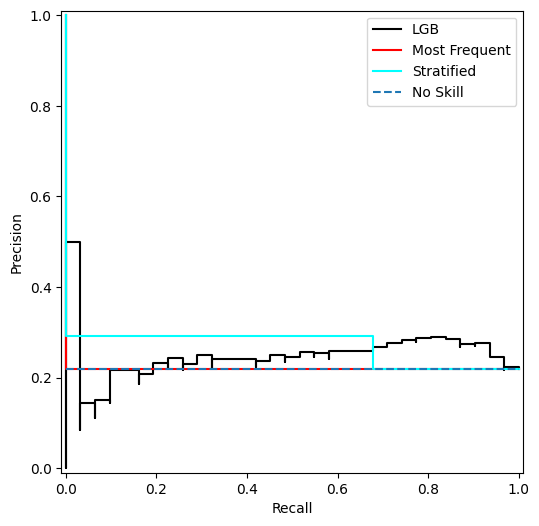

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

label = 1

# best_model, freq_model, strat_model 

best_predict_proba = best_model.predict_proba(scaled_X_test)
freq_dummy_predict_proba = freq_model.predict_proba(scaled_X_test)
strat_predict_proba = strat_model.predict_proba(scaled_X_test)

best_precision, best_recall, _ = precision_recall_curve(y_test, best_predict_proba[:, label])
most_freq_precision, most_freq_recall, _ = precision_recall_curve(y_test, freq_dummy_predict_proba[:, label])
stratified_precision, stratified_recall, _ = precision_recall_curve(y_test, strat_predict_proba[:, label])

no_skill = len(y_test[y_test==label]) / len(y_test)

colors = ['black', 'red', 'lime', 'dodgerblue', 'yellow', 'navy', 'cyan']

# Plot each model's Precision-Recall curve on the same axes
plt.figure(figsize=(8, 6))
lgb_display = PrecisionRecallDisplay(precision=best_precision, recall=best_recall)
lgb_display.plot(label="LGB", color=colors[0], ax=plt.gca())  # plt.gca() gets current axes

freq_display = PrecisionRecallDisplay(precision=most_freq_precision, recall=most_freq_recall)
freq_display.plot(label="Most Frequent", color=colors[1], ax=plt.gca())  # plt.gca() gets current axes

stratified_display = PrecisionRecallDisplay(precision=stratified_precision, recall=stratified_recall)
stratified_display.plot(label="Stratified", color=colors[6], ax=plt.gca())  # plt.gca() gets current axes

plt.gca().plot([0, 1], [no_skill, no_skill], linestyle='--', label='No Skill')

# Add labels and legend
# plt.title("Comparison of Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
# plt.show()

plt.savefig(f'./{folder}/' + f'{folder}-pr-curve.pdf', format='pdf', bbox_inches='tight')

In [54]:
column_renaming_dict = {
    "scale__depth": "depth", 
    "log_norm__depth": "depth", 
    "scale__size": "size", 
    "log_norm__size": "size",
    "scale__max_breadth": "max_breadth", 
    'log_norm__max_breadth': 'max_breadth',
    'scale__virality': 'virality', 
    'log_norm__virality': 'virality',
    'scale__density': 'density', 
    'log_norm__density': 'density',
    'scale__layer_ratio': 'layer_ratio', 
    'log_norm__layer_ratio': 'layer_ratio',
    'scale__structural_heterogeneity': 'structural_heterogeneity',
    'log_norm__structural_heterogeneity': 'structural_heterogeneity',
    'scale__characteristic_distance': 'characteristic_distance',
    'log_norm__characteristic_distance': 'characteristic_distance'

}

renamed_columns = {}
for item in list(scaled_X_test.columns):
    renamed_columns[item] = column_renaming_dict[item]

scaled_X_test = scaled_X_test.rename(columns=renamed_columns)
# scaled_X_test

In [17]:
columns = ['depth', 'size', 'virality', 'density', 'layer_ratio', 'structural_heterogeneity', 'characteristic_distance']
scaled_X_test.columns

Index(['depth', 'size', 'virality', 'density', 'layer_ratio',
       'structural_heterogeneity', 'characteristic_distance'],
      dtype='object')

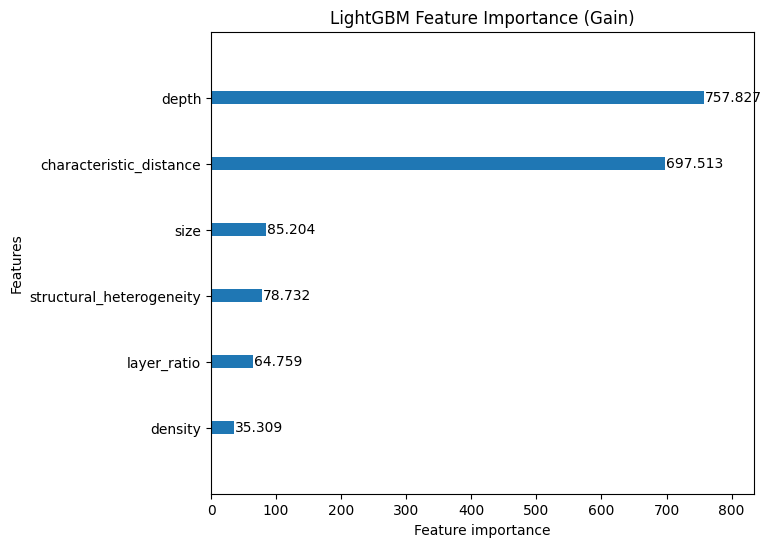

In [9]:
import lightgbm as lgb
import matplotlib.pyplot as plt

# Plot feature importance using Split
lgb.plot_importance(best_model, importance_type="gain", figsize=(7,6), grid=False, title="LightGBM Feature Importance (Gain)")
# plt.show()
plt.savefig(f'./{folder}/' + f'{folder}-lgb-feature-imp.pdf', format='pdf', bbox_inches='tight')

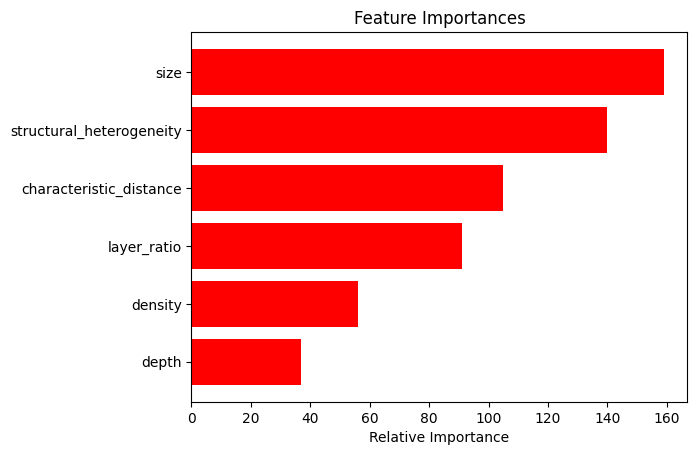

In [11]:
import matplotlib.pyplot as plt

importances = best_model.feature_importances_
indices = np.argsort(best_model.feature_importances_)

plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='red', align='center')
plt.yticks(range(len(indices)), [scaled_X_test.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.savefig(f'./{folder}/' + f'{folder}-feature-imp.pdf', format='pdf', bbox_inches='tight')

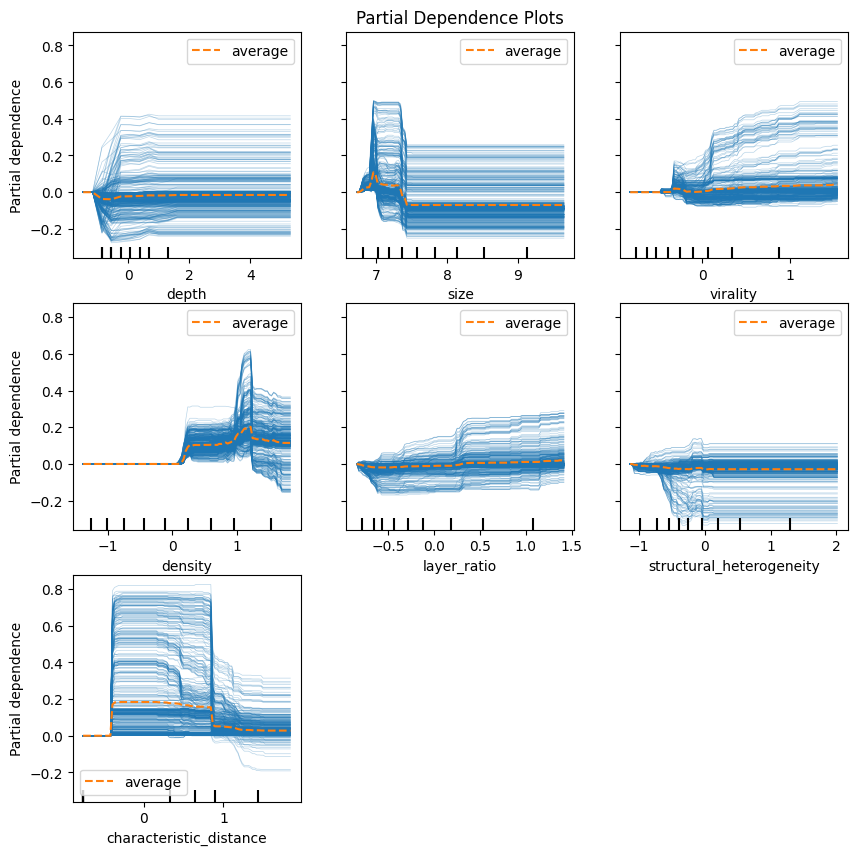

In [24]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title("Partial Dependence Plots")
PartialDependenceDisplay.from_estimator(
    estimator=best_model,
    X=scaled_X_train_val,
    features=list(scaled_X_train_val.columns), # the features to plot
    random_state=5,
    ax=ax,
    kind="both",
    centered=True
)
# plt.show()
# plt.savefig(f'./{folder}/' + f'{folder}-pdp.pdf', format='pdf', bbox_inches='tight')

C:\Users\siddiquee\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


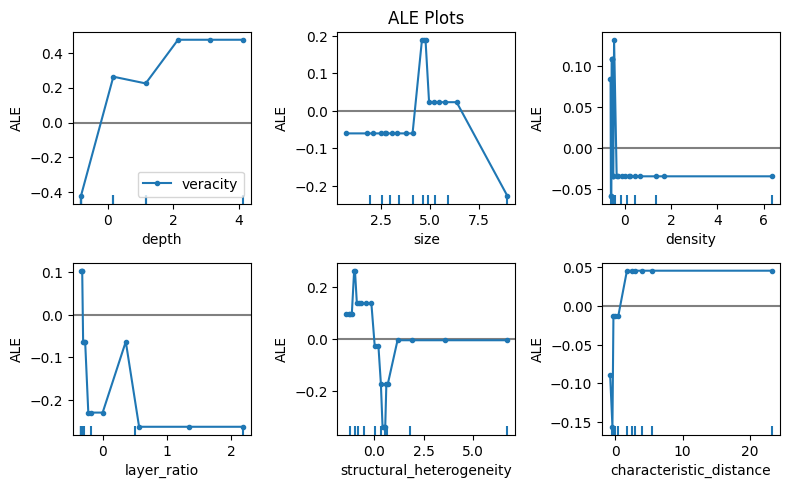

In [13]:
import matplotlib.pyplot as plt
from alibi.explainers import ALE, plot_ale
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title("ALE Plots")

logit_fun_lr = best_model.predict
proba_fun_lr = best_model.predict_proba

logit_ale_lr = ALE(logit_fun_lr, feature_names=list(scaled_X_test.columns), target_names=['veracity'])
proba_ale_lr = ALE(proba_fun_lr, feature_names=list(scaled_X_test.columns), target_names=['veracity'])

logit_exp_lr = logit_ale_lr.explain(scaled_X_test.values)
proba_exp_lr = proba_ale_lr.explain(scaled_X_test.values)

plot_ale(logit_exp_lr, n_cols=3, fig_kw={'figwidth': 8, 'figheight': 5}, sharey=None, ax=ax)

plt.savefig(f'./{folder}/' + f'{folder}-ale.pdf', format='pdf', bbox_inches='tight')

C:\Users\siddiquee\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
ExactExplainer explainer: 71it [00:12,  2.80it/s]                        


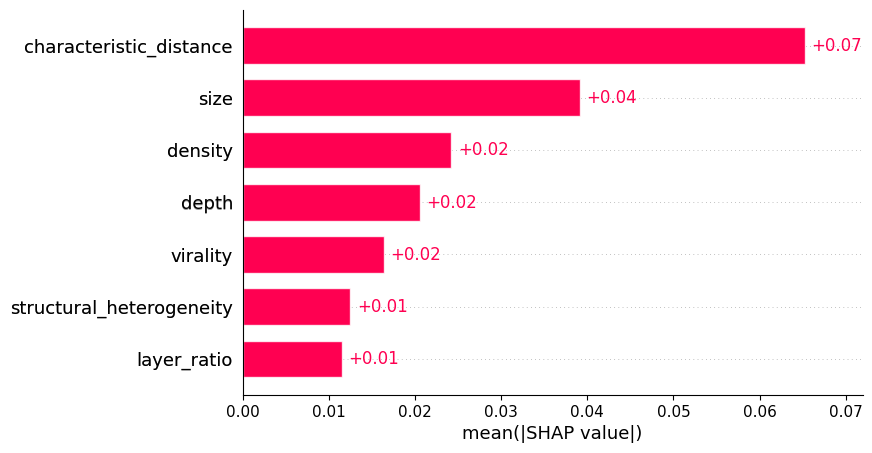

In [26]:
import shap
explainer = shap.Explainer(best_model.predict, scaled_X_test)
# Calculates the SHAP values - It takes some time
shap_values = explainer(scaled_X_test)
shap.plots.bar(shap_values)

In [57]:
# 17, 34, 56, 59
y_test[y_test==1], y_test.iloc[[17]]

(37    1.0
 7     1.0
 42    1.0
 28    1.0
 Name: veracity, dtype: float64,
 37    1.0
 Name: veracity, dtype: float64)

In [77]:
list(best_model.predict(scaled_X_test.iloc[[62]]))[0] ,  list(y_test.iloc[[62]].values)[0]

(1.0, 0.0)

In [75]:
for i in range(0, scaled_X_test.shape[0]):
    if list(best_model.predict(scaled_X_test.iloc[[i]]))[0] != list(y_test.iloc[[i]].values)[0]:
        print(i)

17
34
56
62


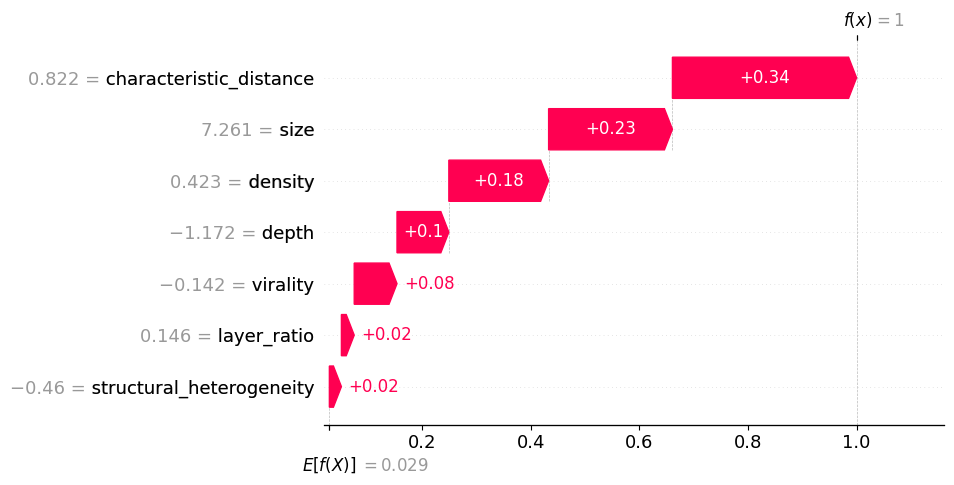

In [80]:
shap.plots.waterfall(shap_values[62])

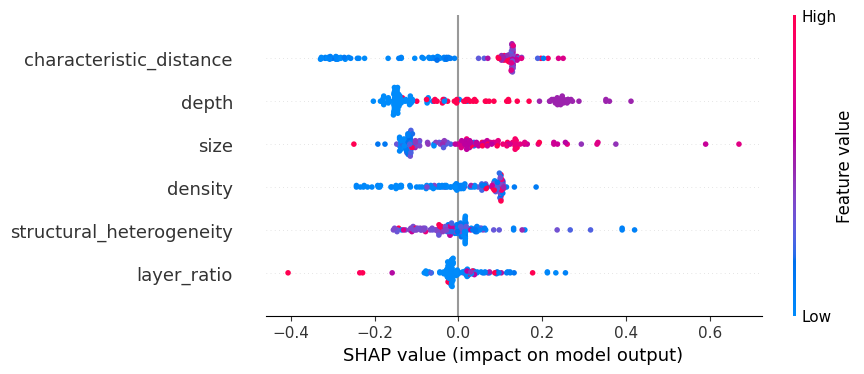

In [15]:
import matplotlib.pyplot as plt

fig=plt.gcf()
shap.plots.beeswarm(shap_values=shap_values)

# plt.show()
# fig.savefig(f'./{folder}/' + f'{folder}-beeswarm.pdf', format='pdf', bbox_inches='tight')


In [86]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(scaled_X_train_val.values,
    feature_names=list(scaled_X_train_val.columns),
    mode='classification')

In [107]:
predict_fn_rf = lambda x: best_model.predict_proba(x).astype(float)
exp = lime_explainer.explain_instance(scaled_X_test.iloc[[62]].values[0], predict_fn_rf, num_features=7)
exp.show_in_notebook(show_all=False)

c:\Program Files\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [14]:
import numpy as np
from scipy.stats import chi2

def rank_data_with_tie_handling(data):
    """
    Ranks data within each block (experiment) while handling ties.
    
    Parameters:
    - data (3D NumPy Array): Experiments × Algorithms × Configurations
    
    Returns:
    - ranked_data (3D NumPy Array): Ranked data with tie handling
    """
    ranked_data = np.zeros(data.shape)
    for exp_idx in range(data.shape[0]):  # Loop through each experiment
        exp_data = data[exp_idx, :, :].flatten()  # Flatten algorithms and configurations
        sorted_indices = np.argsort(-exp_data)  # Sort in descending order
        ranks = np.zeros_like(exp_data)
        
        # Handle ties by assigning the average of tied ranks
        current_rank = 1
        for idx in sorted_indices:
            if np.sum(exp_data[idx] == exp_data[sorted_indices[:sorted_indices.tolist().index(idx)]]) > 0:
                # If this is a tied value, find all tied values and assign average rank
                tied_mask = exp_data == exp_data[idx]
                num_ties = np.sum(tied_mask)
                tied_rank = (current_rank + (current_rank + num_ties - 1)) / 2
                ranks[tied_mask] = tied_rank
                current_rank += num_ties
            else:
                ranks[idx] = current_rank
                current_rank += 1
        
        ranked_data[exp_idx, :, :] = ranks.reshape(6, 2)  # Reshape back
    return ranked_data

def scheirer_ray_hare_test(ranked_data):
    """
    Performs the Scheirer–Ray–Hare test on the ranked data.
    
    Parameters:
    - ranked_data (3D NumPy Array): Ranked data with tie handling
    
    Returns:
    - H (float): Test Statistic
    - df (int): Degrees of Freedom
    - p_value (float): p-value of the test
    """
    # Calculate column sums (configuration sums across all experiments and algorithms)
    config_sums = np.sum(ranked_data, axis=(0, 1))
    
    # Grand sum (total of all ranks)
    grand_sum = np.sum(config_sums)
    
    # Calculate the test statistic (H)
    N = ranked_data.size // 2  # Total number of observations per configuration
    k = 2  # Number of configurations
    n_j = ranked_data.shape[0] * ranked_data.shape[1]  # Number of observations per cell
    H = (12 / (N * (N + 1))) * (np.sum(config_sums**2) / n_j) - 3 * (N + 1)
    
    # Degrees of Freedom
    df = k - 1
    
    # Approximate p-value using chi-square distribution
    p_value = chi2.sf(H, df)
    
    return H, df, p_value

# Example Data (update with your actual data)
np.random.seed(0)  # For reproducibility
data = np.random.rand(4, 6, 2)  # 4 Experiments, 6 Algorithms, 2 Configurations

ranked_data = rank_data_with_tie_handling(data)
H, df, p_value = scheirer_ray_hare_test(ranked_data)

print("Ranked Data (Example):")
print(ranked_data[:, 0, 0])  # Example print, first algorithm across experiments for one config
print("\nScheirer–Ray–Hare Test Results:")
print(f"Test Statistic (H): {H}, Degrees of Freedom: {df}, p-value: {p_value}")

Ranked Data (Example):
[ 7.  8. 11.  7.]

Scheirer–Ray–Hare Test Results:
Test Statistic (H): -33.83833333333333, Degrees of Freedom: 1, p-value: 1.0


In [ ]:
# old style models need this function

# from copy import copy
# import pickle
# import numpy as np
# import pandas as pd
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import StandardScaler, FunctionTransformer

# def read_pickled_data(dataset, feature_selection, quant, dropped_columns, normalization_columns):

#     original_column_order = []
#     prefix = f'../../datasets-for-exp/{dataset}/{dataset}_'
#     order = ['depth', 'size', 'max_breadth', 'virality', 'density', 'layer_ratio',  'structural_heterogeneity',  'characteristic_distance']

#     with open(prefix + 'x_train_val.pickle', "rb") as file:
#         X_train_val = pickle.load(file)

#     with open(prefix + 'y_train_val.pickle' , "rb") as file:
#         y_train_val = pickle.load(file)

#     with open(prefix + 'x_test.pickle',  "rb") as file:
#         X_test = pickle.load(file)

#     with open(prefix + 'y_test.pickle',  "rb") as file:
#         y_test = pickle.load(file)

#     class CustomFunctionTransformer(FunctionTransformer):
#         def get_feature_names_out(self, input_features=None):
#             return input_features

#     log_norm_custom = CustomFunctionTransformer(func=np.log)
    
#     if feature_selection == 1:
#         order = [item for item in order if item not in dropped_columns]
#         normalization_columns = [item for item in normalization_columns if item not in dropped_columns]
#         X_train_val.drop(dropped_columns, axis=1, inplace=True)
#         X_test.drop(dropped_columns, axis=1, inplace=True)
    
#     for item in order:
#         if item in normalization_columns:
#             original_column_order.append('log_norm__'+item)
#         else:
#             original_column_order.append('scale__'+item)

#     normalized_df = copy(X_train_val)
    
#     scaler = StandardScaler()

#     preprocessor = ColumnTransformer([
#         ('log_norm', log_norm_custom, normalization_columns),  # Columns to log-normalize
#         ('scale', scaler, list(set(list(X_train_val.columns)) - set(normalization_columns)))  # Columns to scale
#     ])

#     if quant == True:
#         cd_first_quantile = np.quantile(normalized_df["characteristic_distance"], 0.25)
#         cd_third_quantile = np.quantile(normalized_df["characteristic_distance"], 0.75)
#         normalized_df["characteristic_distance"] = normalized_df["characteristic_distance"] + cd_first_quantile**2 / cd_third_quantile
        
#         test_cd_first_quantile = np.quantile(X_test["characteristic_distance"], 0.25)
#         test_cd_third_quantile = np.quantile(X_test["characteristic_distance"], 0.75)
#         X_test["characteristic_distance"] = X_test["characteristic_distance"] + test_cd_third_quantile
        
#     scaled_X_train_val = preprocessor.fit_transform(normalized_df)
#     scaled_X_test = preprocessor.transform(X_test)

#     transformed_columns = preprocessor.get_feature_names_out()
    
#     scaled_X_train_val_df = pd.DataFrame(scaled_X_train_val, columns=transformed_columns)
#     scaled_X_test_df = pd.DataFrame(scaled_X_test, columns=transformed_columns)

#     scaled_X_train_val_df =  scaled_X_train_val_df[original_column_order]
#     scaled_X_test_df =  scaled_X_test_df[original_column_order]

#     return scaled_X_train_val_df, y_train_val, scaled_X_test_df, y_test